<a href="https://colab.research.google.com/github/Nadantikaa/PyTorch/blob/main/extras/exercises/03_pytorch_computer_vision_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03. PyTorch Computer Vision Exercises

The following is a collection of exercises based on computer vision fundamentals in PyTorch.

They're a bunch of fun.

You're going to get to write plenty of code!

## Resources

1. These exercises are based on [notebook 03 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/03_pytorch_computer_vision/).
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/_PibmqpEyhA).
  * **Note:** Going through these exercises took me just over 3 hours of solid coding, so you should expect around the same.
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [2]:
# Check for GPU
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [3]:
# Import torch
import torch

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# TODO: Setup device agnostic code
device ="cuda" if torch.cuda.is_available() else "cpu"

2.11.0+cpu


## 1. What are 3 areas in industry where computer vision is currently being used?

from IPython.core.interactiveshell import dis
1. Agriculture- to detect crop disease

2.Automative- used in self driving cars

3.Helthcare - detect diseases from CT scans and MRIs

## 2. Search "what is overfitting in machine learning" and write down a sentence about what you find.

Overfitting(high variance) is when the model learns the training data too well and is not able to generalize/ is sensitive to to new data.

## 3. Search "ways to prevent overfitting in machine learning", write down 3 of the things you find and a sentence about each.
> **Note:** there are lots of these, so don't worry too much about all of them, just pick 3 and start with those.

1.Simply the model by using fewer layers or reduce the number of features

2.Dropout- during traning randomly drop few neurons.

3.Train on more data

## 4. Spend 20-minutes reading and clicking through the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/).

* Upload your own example image using the "upload" button on the website and see what happens in each layer of a CNN as your image passes through it.

## 5. Load the [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST) train and test datasets.

In [32]:
import torch, torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

train_data = datasets.MNIST(root="data",
                                   train=True,
                                   download=True,
                                   transform= ToTensor(),
                                   target_transform=None)
test_data = datasets.MNIST(root="data",
                                  train=False,
                                  download=True,
                                  transform= ToTensor(),
                                  target_transform=None)
len(train_data), len(test_data)
train_data.classes

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

## 6. Visualize at least 5 different samples of the MNIST training dataset.

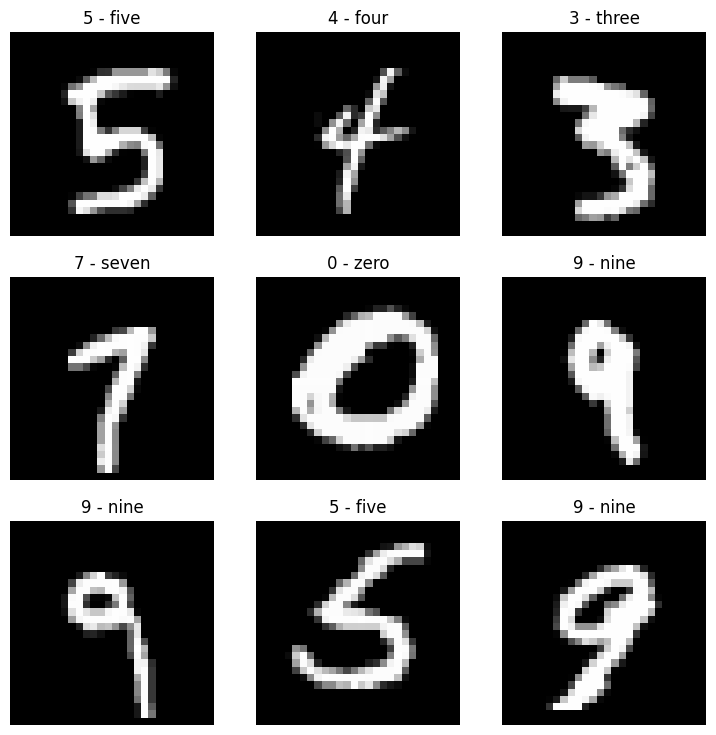

In [5]:
import random
from matplotlib import pyplot as plt
import numpy as np

fig=plt.figure(figsize=(9,9))
class_names = train_data.classes
for i in range(1,9+1):
  random_idx= torch.randint(0,len(train_data), size=[1]).item()
  img, lab = train_data[random_idx]
  fig.add_subplot(3,3,i)
  plt.imshow(img.squeeze(), cmap="gray")
  plt.title(class_names[lab])
  plt.axis(False)


## 7. Turn the MNIST train and test datasets into dataloaders using `torch.utils.data.DataLoader`, set the `batch_size=32`.

In [6]:
from torch.utils.data import DataLoader
BATH_SIZE =32

train_dataload= DataLoader(train_data, batch_size=BATH_SIZE, shuffle=True)
test_dataload= DataLoader(test_data, batch_size=BATH_SIZE, shuffle=False)

## 8. Recreate `model_2` used in notebook 03 (the same model from the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/), also known as TinyVGG) capable of fitting on the MNIST dataset.

In [7]:
from torch import nn


class MNISTModel(nn.Module):
  def __init__(self, input_shape, hidden_units, output_shape):
    super().__init__()
    self.block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=0),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=0),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,
                     stride=2)
    )
    self.block_2 = nn.Sequential(
        nn.Conv2d(hidden_units, hidden_units, 3, padding=0),
        nn.ReLU(),
        nn.Conv2d(hidden_units, hidden_units, 3, padding=0),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*4*4, # Corrected calculation for in_features
                  out_features=output_shape)
    )

  def forward(self,X):
    X= self.block_1(X)
    X= self.block_2(X)
    # print(X.shape) # You can uncomment this to verify the shape after block_2
    X= self.classifier(X)
    return X

model_0 = MNISTModel(input_shape=1,
                              hidden_units=10,
                              output_shape=len(train_data.classes))
model_0

FashionMNISTModelV2(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=160, out_features=10, bias=True)
  )
)

In [8]:
#import helper fucntion
import requests
from pathlib import Path

#download from helper fn from learn pytorch repo
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists")
else:
  print("downloading helper_functions.py")
  request=requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open("helper_functions.py","wb") as f:
    f.write(request.content)
from helper_functions import accuracy_fn

#setup loss fn and opt

loss_fn= nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.1)

downloading helper_functions.py


## 9. Train the model you built in exercise 8. for 5 epochs on CPU and GPU and see how long it takes on each.

In [36]:

from timeit import default_timer as timer
device="cpu"
model_0.to(device)
epoch = 5

start_time_on_cpu= timer()
for epochs in range(epoch):
  train_loss = 0
  train_acc = 0
  for batch, (X,y) in enumerate(train_dataload):
    # Pass data to the model
    X,y = X.to(device), y.to(device)
    y_preds = model_0(X)
    # Calculate loss
    loss=loss_fn(y_preds, y)
    train_loss += loss
    # Calculate accuracy by converting logits to predicted labels
    acc = accuracy_fn(y_true=y, y_pred=y_preds.argmax(dim=1))
    train_acc += acc
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  train_loss /= len(train_dataload)
  train_acc /= len(train_dataload)


  ##testing
  test_loss, test_acc =0,0
  model_0.eval()
  with torch.inference_mode():
    for X,y in test_dataload:
      X,y = X.to(device), y.to(device)
      test_preds = model_0(X)
      test_loss += loss_fn(test_preds, y)
      test_acc += accuracy_fn(y_true=y, y_pred=test_preds.argmax(dim=1))
    test_loss /= len(test_dataload)
    test_acc /= len(test_dataload)
  print(f"Epoch: {epochs} | Train Loss: {train_loss:.2f} | Train Acc: {train_acc:.2f} | Test Loss: {test_loss:.2f} | Test Acc: {test_acc:.2f}")

stop_time_on_cpu = timer()
total_time_on_cpu = stop_time_on_cpu - start_time_on_cpu
print(f"Total training time on CPU: {total_time_on_cpu}")

Epoch: 0 | Train Loss: 0.05 | Train Acc: 98.55 | Test Loss: 0.05 | Test Acc: 98.32
Epoch: 1 | Train Loss: 0.05 | Train Acc: 98.55 | Test Loss: 0.05 | Test Acc: 98.32
Epoch: 2 | Train Loss: 0.05 | Train Acc: 98.55 | Test Loss: 0.05 | Test Acc: 98.32
Epoch: 3 | Train Loss: 0.05 | Train Acc: 98.55 | Test Loss: 0.05 | Test Acc: 98.32
Epoch: 4 | Train Loss: 0.05 | Train Acc: 98.55 | Test Loss: 0.05 | Test Acc: 98.32
Total training time on CPU: 258.0934131509998


In [37]:
#Connect to gpu
from timeit import default_timer as timer
device ="cuda"
model_0.to(device)
epoch = 5

start_time_on_gpu= timer()
for epochs in range(epoch):
  train_loss = 0
  train_acc = 0
  for batch, (X,y) in enumerate(train_dataload):
    # Pass data to the model
    X,y = X.to(device), y.to(device)
    y_preds = model_0(X)
    # Calculate loss
    loss=loss_fn(y_preds, y)
    train_loss += loss
    # Calculate accuracy by converting logits to predicted labels
    acc = accuracy_fn(y_true=y, y_pred=y_preds.argmax(dim=1))
    train_acc += acc
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  train_loss /= len(train_dataload)
  train_acc /= len(train_dataload)


  ##testing
  test_loss, test_acc =0,0
  model_0.eval()
  with torch.inference_mode():
    for X,y in test_dataload:
      X,y = X.to(device), y.to(device)
      test_preds = model_0(X)
      test_loss += loss_fn(test_preds, y)
      test_acc += accuracy_fn(y_true=y, y_pred=test_preds.argmax(dim=1))
    test_loss /= len(test_dataload)
    test_acc /= len(test_dataload)
  print(f"Epoch: {epochs} | Train Loss: {train_loss:.2f} | Train Acc: {train_acc:.2f} | Test Loss: {test_loss:.2f} | Test Acc: {test_acc:.2f}")

stop_time_on_gpu = timer()
total_time_on_gpu = stop_time_on_gpu - start_time_on_gpu
print(f"Total training time on GPU: {total_time_on_gpu}")

AssertionError: Torch not compiled with CUDA enabled

## 10. Make predictions using your trained model and visualize at least 5 of them comparing the prediciton to the target label.

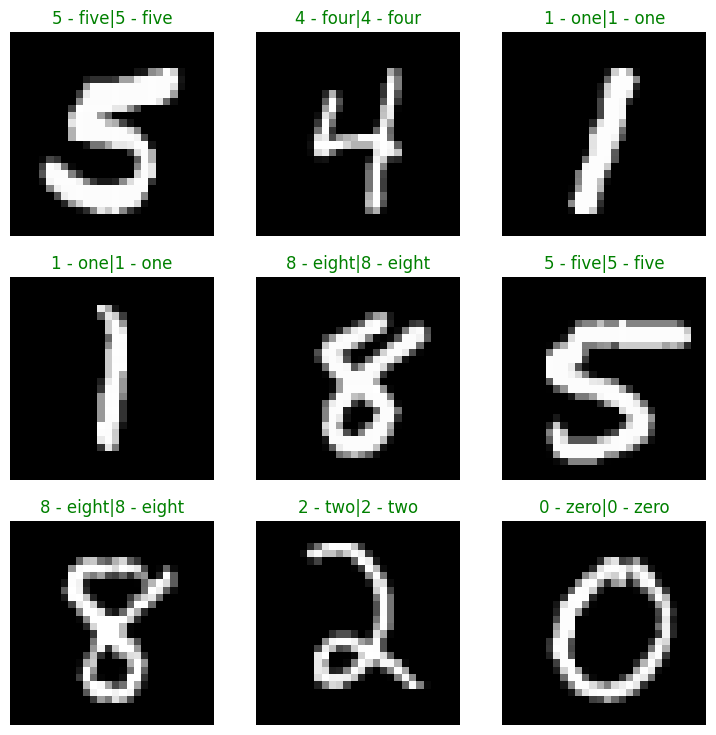

In [11]:
## make predicitions
model_0.eval()
y_preds=[] ##saving the predictions
with torch.inference_mode():
  for X,y in test_dataload:
    test_logits = model_0(X)
    y_pred=(test_logits.argmax(dim=1))
    y_preds.append(y_pred.cpu())
y_preds = torch.cat(y_preds) #put it to cpu so we can plot it

test_preds, y

fig=plt.figure(figsize=(9,9))
class_names = test_data.classes
for i in range(1,9+1):
  random_idx= torch.randint(0,len(test_data), size=[1]).item()
  img,label= test_data[random_idx]
  fig.add_subplot(3,3,i)
  plt.imshow(img.squeeze(), cmap="gray")
  if class_names[label] == class_names[y_preds[random_idx]]:
    plt.title(class_names[label]+"|"+class_names[y_preds[random_idx]], color="green")
  else:
    plt.title(class_names[label]+"|"+class_names[y_preds[random_idx]], color="red")
  plt.axis(False)


## 11. Plot a confusion matrix comparing your model's predictions to the truth labels.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 22.5 MB/s eta 0:00:00


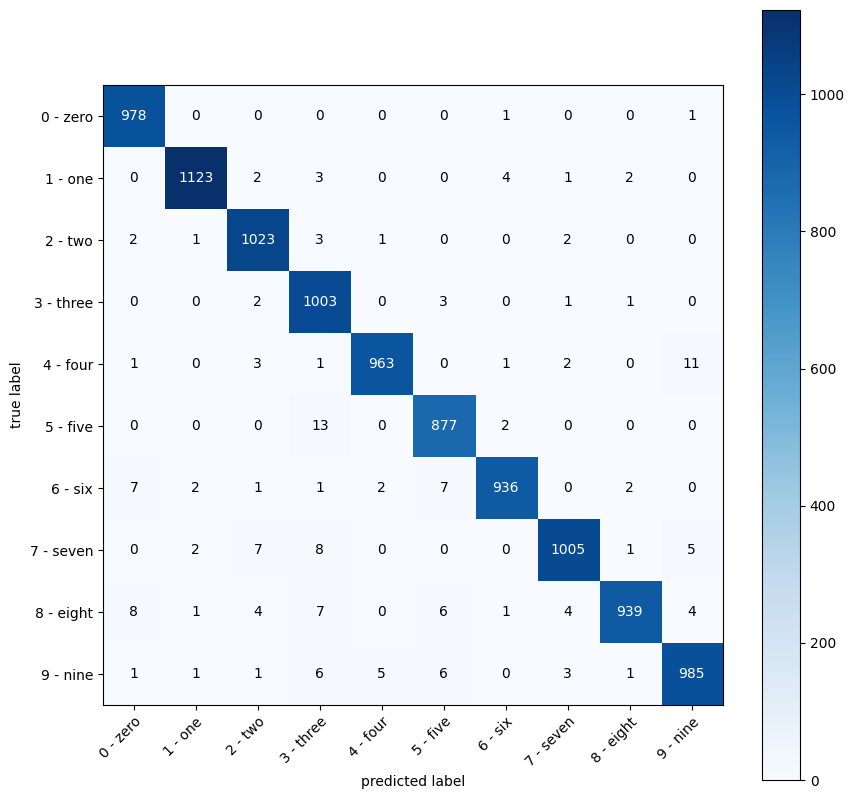

In [12]:
!pip install -q torchmetrics
import torchmetrics,mlxtend
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

confmat =ConfusionMatrix(task="MULTICLASS",
                          num_classes=len(class_names))

#call anf convert to tensor
confmat_tesor = confmat(preds=y_preds,
                        target= test_data.targets)

fig= plot_confusion_matrix(confmat_tesor.numpy(),
                           class_names=class_names,
                           figsize=(10,10),
                           colorbar=True)

## 12. Create a random tensor of shape `[1, 3, 64, 64]` and pass it through a `nn.Conv2d()` layer with various hyperparameter settings (these can be any settings you choose), what do you notice if the `kernel_size` parameter goes up and down?

In [13]:
random = torch.rand((1,3,64,64))

conv_layer = nn.Conv2d(in_channels=3,
                       out_channels=1,
                       kernel_size=3,
                       stride=1,
                       padding=1)
conv_layer(random).shape

torch.Size([1, 1, 64, 64])

In [14]:
random = torch.rand((1,3,64,64))

conv_layer = nn.Conv2d(in_channels=3,
                       out_channels=1,
                       kernel_size=2,
                       stride=1,
                       padding=1)
conv_layer(random).shape

torch.Size([1, 1, 65, 65])

In [15]:
random = torch.rand((1,3,64,64))

conv_layer = nn.Conv2d(in_channels=3,
                       out_channels=1,
                       kernel_size=3,
                       stride=1,
                       padding=0)
conv_layer(random).shape

torch.Size([1, 1, 62, 62])

## 13. Use a model similar to the trained `model_2` from notebook 03 to make predictions on the test [`torchvision.datasets.FashionMNIST`](https://pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html) dataset.
* Then plot some predictions where the model was wrong alongside what the label of the image should've been.
* After visualing these predictions do you think it's more of a modelling error or a data error?
* As in, could the model do better or are the labels of the data too close to each other (e.g. a "Shirt" label is too close to "T-shirt/top")?

In [16]:
# Download FashionMNIST train & test
from torchvision import datasets
from torchvision import transforms

fashion_mnist_train = datasets.FashionMNIST(root=".",
                                            download=True,
                                            train=True,
                                            transform=transforms.ToTensor())

fashion_mnist_test = datasets.FashionMNIST(root=".",
                                           train=False,
                                           download=True,
                                           transform=transforms.ToTensor())

len(fashion_mnist_train), len(fashion_mnist_test)

100%|██████████| 26.4M/26.4M [00:00<00:00, 108MB/s] 
100%|██████████| 29.5k/29.5k [00:00<00:00, 11.4MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 56.0MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.7MB/s]


(60000, 10000)

In [17]:
# Get the class names of the Fashion MNIST dataset
fashion_mnist_class_names = fashion_mnist_train.classes
fashion_mnist_class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [23]:
# Turn FashionMNIST datasets into dataloaders
from torch.utils.data import DataLoader

train_dataloader = DataLoader(fashion_mnist_train,
                                            batch_size=32,
                                            shuffle=True)

test_dataloader = DataLoader(fashion_mnist_test,
                                           batch_size=32,
                                           shuffle=False)

len(train_dataloader), len(test_dataloader)

(1875, 313)

In [24]:
device ="cuda" if torch.cuda.is_available() else "cpu"
# create a convolitional neural network

class FashionMNISTModelV3(nn.Module):
  """
  Model architecture that replicates the TinyVGG
  model from CNN explainer Websit.
  """
  def __init__(self,
               input_shape:int,
               hidden_units:int,
               output_shape:int):
    super().__init__()
    #A block in a CNN is simply a group of layers that perform one stage of feature extraction.
    #feature extractor
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3, #3x3
                  stride=1,
                  padding=1), #hyperparamets of conv2d
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, #2x2
                     stride=2)
    )

    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(hidden_units,
                  hidden_units,
                  kernel_size=3,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(hidden_units,
                  hidden_units,
                  kernel_size=3,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,
                     stride=2)
    )

    self.conv_block_3 = nn.Sequential(
        nn.Conv2d(hidden_units,
                  hidden_units,
                  kernel_size=3,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(hidden_units,
                  hidden_units,
                  kernel_size=3,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,
                     stride=2)
    )

    ##Classifier model
    self.classifier= nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*3*3, #ONE theres trick to calculate this
                  out_features=output_shape)
    )

  def forward(self, X):
    X=self.conv_block_1(X)
    #print(f"Output shape of conv_block_1:0:{X.shape}")
    X=self.conv_block_2(X)
    #print(f"Output shape of conv_block_2:0:{X.shape}")
    X= self.conv_block_3(X)
    #print(f"Output shape of conv_block_3:{X.shape}")
    return self.classifier(X)
    #return self.classifier(self.conv_block_2(self.conv_block_1(X)))



In [ ]:
device

In [20]:
torch.manual_seed(42)

#PyTorch randomly initializes all the weights and biases.
model_2 =FashionMNISTModelV3(input_shape=1, #one color channel
                             #The 28×28 isn't passed as input_shape because the convolution layer automatically works with whatever spatial size it receives.
                             hidden_units=16,
                             output_shape=len(class_names)).to(device)
model_2

FashionMNISTModelV3(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_3): Sequential(
    (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): L

In [21]:
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(),
                           lr=0.1)
acc_fn= accuracy_fn

print(acc_fn)

<function accuracy_fn at 0x7c91c4c4bb00>


In [26]:
from timeit import default_timer as timer

epoch = 5

start_time_on_gpu= timer()
for epochs in range(epoch):
  train_loss = 0
  train_acc = 0
  model_2.train()
  for batch, (X,y) in enumerate(train_dataloader):
    # Pass data to the model
    X,y = X.to(device), y.to(device)

    y_preds = model_2(X)
    # Calculate loss
    loss=loss_fn(y_preds, y)
    train_loss += loss
    # Calculate accuracy by converting logits to predicted labels
    acc = accuracy_fn(y_true=y, y_pred=y_preds.argmax(dim=1))
    train_acc += acc
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  train_loss /= len(train_dataloader)
  train_acc /= len(train_dataloader)


  ##testing
  test_loss, test_acc =0,0
  model_2.eval()
  with torch.inference_mode():
    for X,y in test_dataloader:
      X,y = X.to(device), y.to(device)
      test_preds = model_2(X)
      test_loss += loss_fn(test_preds, y)
      test_acc += accuracy_fn(y_true=y, y_pred=test_preds.argmax(dim=1))
    test_loss /= len(test_dataloader)
    test_acc /= len(test_dataloader)
  print(f"Epoch: {epochs} | Train Loss: {train_loss:.2f} | Train Acc: {train_acc:.2f} | Test Loss: {test_loss:.2f} | Test Acc: {test_acc:.2f}")

stop_time_on_gpu = timer()
total_time_on_gpu = stop_time_on_gpu - start_time_on_gpu
print(f"Total training time on GPU: {total_time_on_gpu}")

Epoch: 0 | Train Loss: 0.49 | Train Acc: 82.47 | Test Loss: 0.39 | Test Acc: 86.05
Epoch: 1 | Train Loss: 0.35 | Train Acc: 87.07 | Test Loss: 0.41 | Test Acc: 84.61
Epoch: 2 | Train Loss: 0.32 | Train Acc: 88.37 | Test Loss: 0.34 | Test Acc: 88.04
Epoch: 3 | Train Loss: 0.30 | Train Acc: 88.94 | Test Loss: 0.33 | Test Acc: 87.85
Epoch: 4 | Train Loss: 0.29 | Train Acc: 89.44 | Test Loss: 0.31 | Test Acc: 88.65
Total training time on GPU: 390.443242047


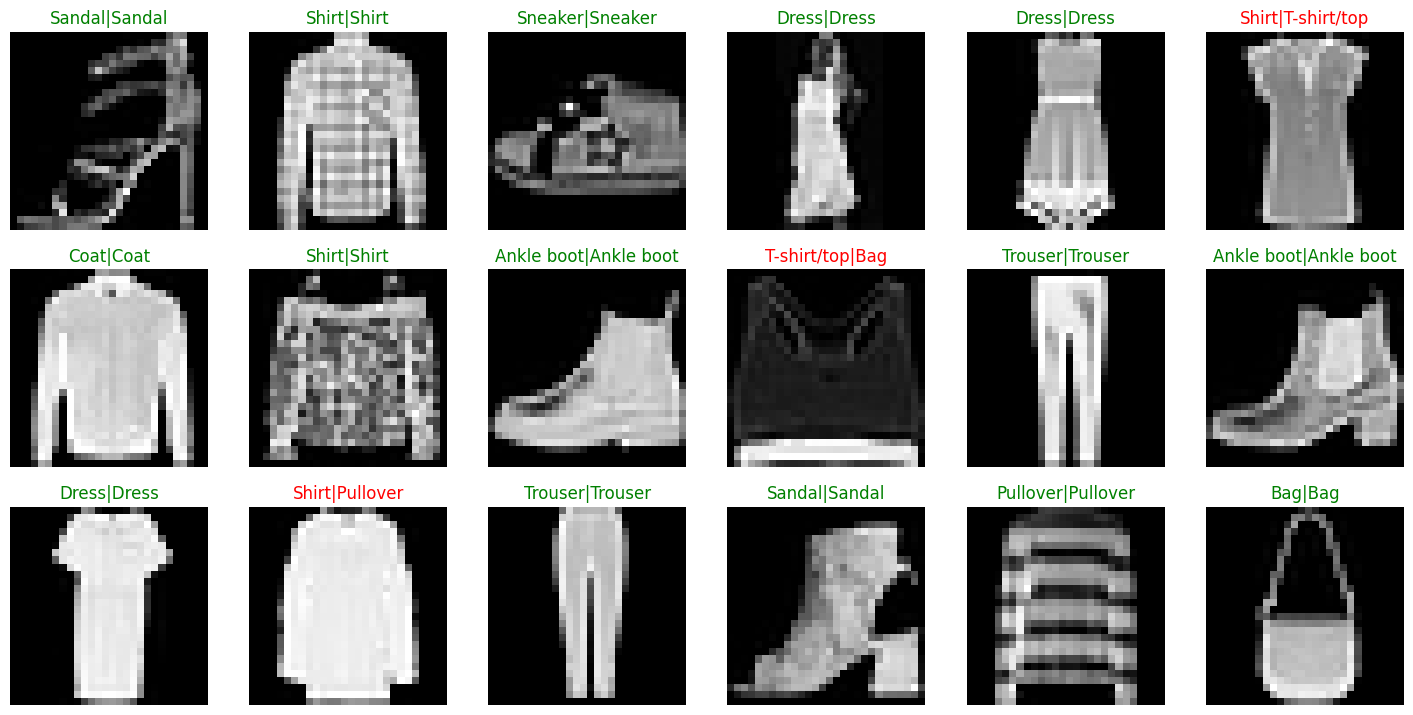

In [35]:
## make predicitions
model_2.to(device)
model_2.eval()
y_test_preds=[] ##saving the predictions
with torch.inference_mode():
  for X,y in test_dataloader:
    X,y = X.to(device), y.to(device)
    test_logits = model_2(X)
    y_pred=(test_logits.argmax(dim=1))
    y_test_preds.append(y_pred.cpu())
y_test_preds_tensor = torch.cat(y_test_preds) #put it to cpu so we can plot it


test_preds, y

fig=plt.figure(figsize=(18,18))
class_names = fashion_mnist_test.classes
for i in range(1,18+1):
  random_idx= torch.randint(0,len(fashion_mnist_test), size=[1]).item()
  img,label= fashion_mnist_test[random_idx]
  fig.add_subplot(6,6,i)
  plt.imshow(img.squeeze(), cmap="gray")
  if class_names[label] == class_names[y_test_preds_tensor[random_idx]]:
    plt.title(class_names[label]+"|"+class_names[y_test_preds_tensor[random_idx]], color="green")
  else:
    plt.title(class_names[label]+"|"+class_names[y_test_preds_tensor[random_idx]], color="red")
  plt.axis(False)


I have added an extra block and have increased the number of hidden layers
yet from the look of some of these predictions, the model's accuracy hasnt imporoved noticebly

For example it predicts "Sneaker" instead of "Sandal" when it could have easily been a "Sneaker".

The same goes for the confusion between the classes of "T-shirt/top" and "Shirt", many of the examples here look similar.